<a href="https://colab.research.google.com/github/replysantosh-lang/ECARDeepLearning/blob/main/amazonreviewtoscore_deepika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load the data
df = pd.read_csv('/content/drive/MyDrive/Day1/amazon_review1k.csv',on_bad_lines='skip',encoding='utf-8')

# df = df.head(10000)
# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nScore distribution:")
print(df['Score'].value_counts().sort_index())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (999, 10)

First few rows:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bough

In [6]:
# Clean the text data
def preprocess_text(text):
    """Basic text preprocessing"""
    if pd.isna(text):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Apply preprocessing
df['processed_text'] = df['Text'].apply(preprocess_text)

# Remove any rows with missing text or scores
df = df.dropna(subset=['processed_text', 'Score'])

print(f"Dataset after cleaning: {df.shape}")

Dataset after cleaning: (999, 11)


In [7]:
# Split features and target
X = df['processed_text'].values
y = df['Score'].values

# For classification (if treating scores as classes)
# Convert scores to categorical (0-indexed)
y_categorical = y - 1  # Assuming scores are 1-5, convert to 0-4

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 799
Test set size: 200


In [8]:
# Tokenization parameters
MAX_WORDS = 10000  # Maximum number of words in vocabulary
MAX_SEQUENCE_LENGTH = 200  # Maximum length of each review
EMBEDDING_DIM = 100  # Dimension of word embeddings

# Create and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure uniform length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Get vocabulary size
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 5392


In [10]:
# Define model architecture
def create_lstm_model(vocab_size, embedding_dim, max_length, num_classes=5):
    """
    Create LSTM model for review score prediction
    """
    model = keras.Sequential([
        # Embedding layer
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_length,
            mask_zero=True
        ),

        # LSTM layers
        layers.LSTM(128, dropout=0.5, recurrent_dropout=0.2, return_sequences=True),
        layers.LSTM(64, dropout=0.5, recurrent_dropout=0.2),

        # Dense layers
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.5),

        # Output layer for classification (5 classes for scores 1-5)
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create the model
model = create_lstm_model(vocab_size, EMBEDDING_DIM, MAX_SEQUENCE_LENGTH)

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Define callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

# Train the model
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train_pad, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5510 - loss: 1.4976 - val_accuracy: 0.6375 - val_loss: 1.1401 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.6370 - loss: 1.1926 - val_accuracy: 0.6375 - val_loss: 1.1408 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.6494 - loss: 1.1788 - val_accuracy: 0.6375 - val_loss: 1.1234 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.6311 - loss: 1.1090 - val_accuracy: 0.5875 - val_loss: 1.1826 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6998 - loss: 0.9154 - val_accuracy: 0.5688 - val_loss: 1.1810 - learning_rate: 0.0010
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.7380 - loss: 0.7206 - val_accuracy: 0.5875 - val_loss: 1.2529 - learning_rate: 5.0000e-04


In [12]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert back to original scale (1-5)
y_pred_scores = y_pred + 1
y_test_scores = y_test + 1


Test Loss: 1.1131
Test Accuracy: 0.6400
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 440ms/step


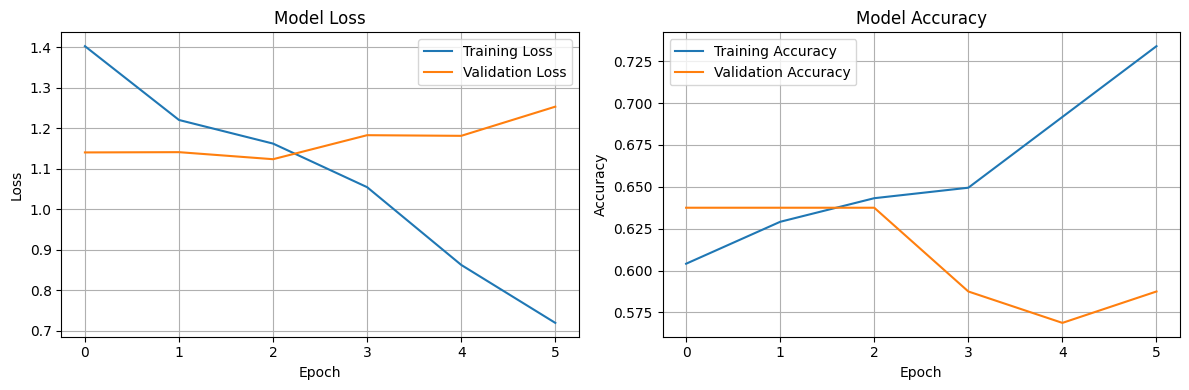

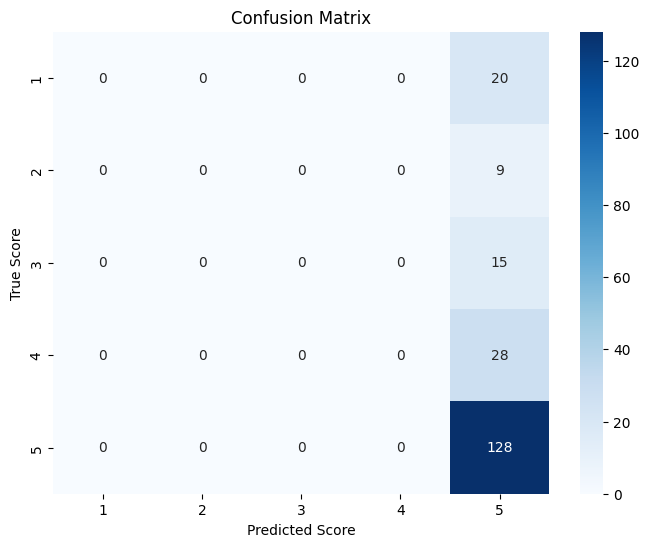


Classification Report:
              precision    recall  f1-score   support

     Score 1       0.00      0.00      0.00        20
     Score 2       0.00      0.00      0.00         9
     Score 3       0.00      0.00      0.00        15
     Score 4       0.00      0.00      0.00        28
     Score 5       0.64      1.00      0.78       128

    accuracy                           0.64       200
   macro avg       0.13      0.20      0.16       200
weighted avg       0.41      0.64      0.50       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test_scores, y_pred_scores)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 6), yticklabels=range(1, 6))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Score')
plt.ylabel('True Score')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_scores, y_pred_scores, target_names=[f'Score {i}' for i in range(1, 6)]))


In [14]:
# Option to use pre-trained embeddings (e.g., GloVe)
def load_glove_embeddings(glove_file_path, word_index, embedding_dim=100):
    """
    Load GloVe embeddings and create embedding matrix
    """
    embeddings_index = {}

    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    # Create embedding matrix
    embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
    for word, i in word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

    return embedding_matrix

# If using pre-trained embeddings, modify the model:
def create_lstm_with_pretrained(vocab_size, embedding_matrix, max_length, num_classes=5):
    """
    Create LSTM model with pre-trained embeddings
    """
    embedding_dim = embedding_matrix.shape[1]

    model = keras.Sequential([
        # Pre-trained embedding layer
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_length,
            weights=[embedding_matrix],
            trainable=False  # Freeze pre-trained embeddings
        ),

        # Rest of the model remains the same
        layers.LSTM(128, dropout=0.5, recurrent_dropout=0.2, return_sequences=True),
        layers.LSTM(64, dropout=0.5, recurrent_dropout=0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model


In [17]:
def predict_score(text, model, tokenizer, max_length=MAX_SEQUENCE_LENGTH):
    """
    Predict score for a new review text
    """
    # Preprocess text
    processed_text = preprocess_text(text)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([processed_text])

    # Pad sequence
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')

    # Make prediction
    prediction_probs = model.predict(padded_sequence, verbose=0)
    predicted_class = np.argmax(prediction_probs[0])
    predicted_score = predicted_class + 1  # Convert back to 1-5 scale

    return predicted_score, prediction_probs[0]

# Example usage
sample_text = "This product is very bad."
predicted_score, probabilities = predict_score(sample_text, model, tokenizer)

print(f"Review: {sample_text}")
print(f"Predicted Score: {predicted_score}")
print(f"Score Probabilities:")
for i, prob in enumerate(probabilities):
    print(f"  Score {i+1}: {prob:.3f}")


Review: This product is very bad.
Predicted Score: 5
Score Probabilities:
  Score 1: 0.162
  Score 2: 0.151
  Score 3: 0.159
  Score 4: 0.178
  Score 5: 0.350


In [18]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv("/content/drive/MyDrive/Day1/amazon_review1k.csv")

# Keep only required columns
df = df[['Text','Score']]

# -----------------------------
# 2. Convert Score to Sentiment
# Positive = Score >=4
# Negative = Score <=3
# -----------------------------
df['label'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

texts = df['Text'].astype(str)
labels = df['label']

# -----------------------------
# 3. Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# -----------------------------
# 4. Tokenization
# -----------------------------
vocab_size = 10000
max_len = 150

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(train_sequences, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_len, padding='post')

# -----------------------------
# 5. Build LSTM Model (4 Layers)
# -----------------------------
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# LSTM Layer 1
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.3))

# LSTM Layer 2
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.3))

# LSTM Layer 3
model.add(LSTM(32, return_sequences=True))
model.add(Dropout(0.3))

# LSTM Layer 4
model.add(LSTM(16))
model.add(Dropout(0.3))

# Dense Output Layer
model.add(Dense(1, activation='sigmoid'))

# -----------------------------
# 6. Compile Model
# -----------------------------
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 7. Train Model
# -----------------------------
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# -----------------------------
# 8. Predictions
# -----------------------------
pred_probs = model.predict(X_test_pad)

# Convert probabilities → binary labels
y_pred = (pred_probs > 0.5).astype(int)

# -----------------------------
# 9. Precision & Recall
# -----------------------------
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\nPrecision:", precision)
print("Recall:", recall)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.7766 - loss: 0.5984 - val_accuracy: 0.7937 - val_loss: 0.5089
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7498 - loss: 0.5842 - val_accuracy: 0.7937 - val_loss: 0.5083
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7912 - loss: 0.5132 - val_accuracy: 0.7937 - val_loss: 0.5006
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8077 - loss: 0.5120 - val_accuracy: 0.7812 - val_loss: 0.5177
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7883 - loss: 0.5040 - val_accuracy: 0.7875 - val_loss: 0.5057
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7752 - loss: 0.5226 - val_accuracy: 0.7937 - val_loss: 0.5042
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7605 - loss: 0.5567 - val_accuracy: 0.7937 - val_loss: 0.5039
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7703 - loss: 0.5561 - val_accuracy: 0.7937 - v

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
